# Gaussian Process Regression from Scratch for Energy Efficiency Prediction

This notebook presents an implementation of **Gaussian Process Regression (GPR) from scratch** to predict the Heating Load (`Y1`) of buildings based on their structural features. All kernels, predictive GPR math, and baseline regressors are implemented from scratch using NumPy and Pandas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Vectorized Cholesky Solver from Scratch
def cholesky_scratch(A):
    N = A.shape[0]
    L = np.zeros((N, N))
    for j in range(N):
        val = A[j, j] - np.sum(L[j, :j]**2)
        if val <= 0:
            val = 1e-12
        L[j, j] = np.sqrt(val)
        if j < N - 1:
            L[j+1:, j] = (A[j+1:, j] - np.dot(L[j+1:, :j], L[j, :j])) / L[j, j]
    return L


## 2. Dataset Ingestion and Inspection


In [2]:
df = pd.read_csv('ENB2012_data.csv')
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (768, 10)
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


In [3]:
X = df.iloc[:, :-2].values
Y = df['Y1'].values
print("Features shape:", X.shape)
print("Target shape:", Y.shape)


Features shape: (768, 8)
Target shape: (768,)


### 2.3 Train-Test Split & Feature Z-score Standardization

We split the data randomly (60/40) and standardize the features using only the training set statistics to prevent data leakage.


In [4]:
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.6 * len(X))

X_train_raw = X[indices[:train_size]]
X_test_raw = X[indices[train_size:]]
Y_train_orig = Y[indices[:train_size]]
Y_test_orig = Y[indices[train_size:]]

# Standardization parameters from training set
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

Y_mean = np.mean(Y_train_orig)
Y_std = np.std(Y_train_orig) + 1e-8
Y_train_norm = (Y_train_orig - Y_mean) / Y_std
Y_test_norm = (Y_test_orig - Y_mean) / Y_std

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (460, 8), Test set: (308, 8)


### 2.4 Calculating Noise Variance dynamically from Dataset

We fit a multiple linear regression model to the standardized training data and estimate the noise variance as the variance of the training residuals.


In [5]:
X_tr_b = np.hstack([np.ones((len(X_train), 1)), X_train])
w_noise = np.linalg.solve(X_tr_b.T @ X_tr_b + 1e-8 * np.eye(X_tr_b.shape[1]), X_tr_b.T @ Y_train_norm)
noise = np.var(Y_train_norm - X_tr_b @ w_noise)
print("Estimated Noise Variance (sigma_n^2):", noise)


Estimated Noise Variance (sigma_n^2): 0.08587998114645025


## 3. GPR Implementation with RBF Kernel


In [6]:
def sq_dist(X1, X2):
    return np.maximum(np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T), 0)

def dist(X1, X2):
    return np.sqrt(sq_dist(X1, X2))

def rbf_kernel(X1, X2, l=1.5, sigma_f=1.0):
    return sigma_f**2 * np.exp(-0.5 / l**2 * sq_dist(X1, X2))


In [7]:
def gp_regression(X_train, Y_train, X_test, kernel_func, noise_var=1e-2, **kwargs):
    K = kernel_func(X_train, X_train, **kwargs)
    K_s = kernel_func(X_train, X_test, **kwargs)
    K_ss = kernel_func(X_test, X_test, **kwargs)
    
    # Stable inversion using Cholesky
    L = cholesky_scratch(K + noise_var * np.eye(len(X_train)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
    mu = K_s.T.dot(alpha)
    
    v = np.linalg.solve(L, K_s)
    cov = K_ss - v.T.dot(v)
    var = np.diag(cov)
    
    return mu, var


In [8]:
mu_norm, var_norm = gp_regression(X_train, Y_train_norm, X_test, rbf_kernel, noise_var=noise)
mu_orig = mu_norm * Y_std + Y_mean
std_orig = np.sqrt(np.abs(var_norm)) * Y_std
lower = mu_orig - 1.96 * std_orig
upper = mu_orig + 1.96 * std_orig


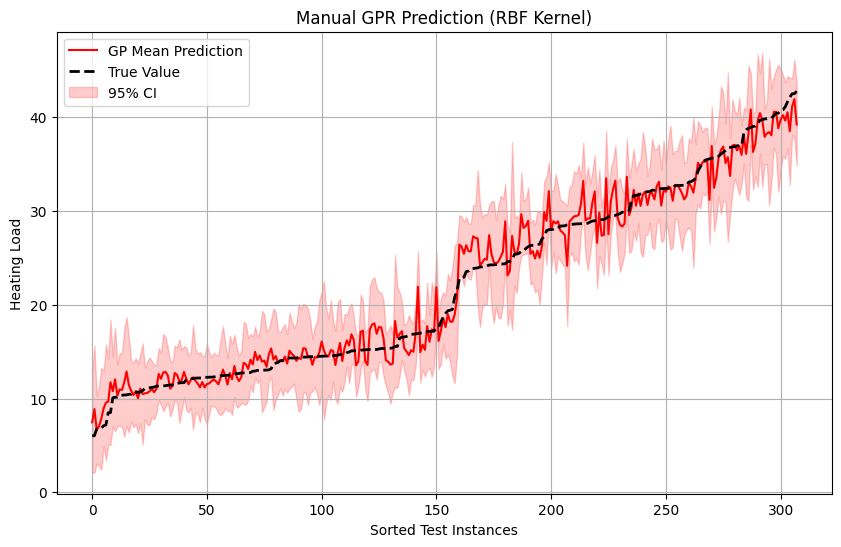

In [9]:
sort_idx = np.argsort(Y_test_orig)
Y_test_sorted = Y_test_orig[sort_idx]
x_axis = np.arange(len(Y_test_sorted))

plt.figure(figsize=(10,6))
plt.plot(x_axis, mu_orig[sort_idx], 'r-', label='GP Mean Prediction', linewidth=1.5)
plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
plt.fill_between(x_axis, lower[sort_idx], upper[sort_idx], color='red', alpha=0.2, label='95% CI')
plt.xlabel("Sorted Test Instances")
plt.ylabel("Heating Load")
plt.title("Manual GPR Prediction (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R², NLL)


In [10]:
rmse = np.sqrt(np.mean((Y_test_orig - mu_orig)**2))
mae = np.mean(np.abs(Y_test_orig - mu_orig))
ss_res = np.sum((Y_test_orig - mu_orig)**2)
ss_tot = np.sum((Y_test_orig - np.mean(Y_test_orig))**2)
r2 = 1 - ss_res / ss_tot

var_orig = np.clip(var_norm * (Y_std**2), 1e-12, None)
log_pdf = -0.5 * np.log(2 * np.pi * var_orig) - ((Y_test_orig - mu_orig)**2) / (2 * var_orig)
nll = -np.mean(log_pdf)

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)
print("NLL =", nll)


RMSE = 1.5425727070379305
MAE = 1.1485387145460728
R2 = 0.9755185237951023
NLL = 1.9381349454330459


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We implement Matern 3/2, Matern 5/2, Rational Quadratic, Linear, and RBF+RQ Hybrid kernels from scratch.


In [11]:
def matern32_kernel(X1, X2, l=1.5, sigma_f=1.0):
    r = dist(X1, X2)
    return sigma_f**2 * (1.0 + np.sqrt(3.0)*r/l) * np.exp(-np.sqrt(3.0)*r/l)

def matern52_kernel(X1, X2, l=1.5, sigma_f=1.0):
    r = dist(X1, X2)
    sq_r = sq_dist(X1, X2)
    return sigma_f**2 * (1.0 + np.sqrt(5.0)*r/l + 5.0*sq_r/(3.0*l**2)) * np.exp(-np.sqrt(5.0)*r/l)

def rq_kernel(X1, X2, l=1.5, sigma_f=1.0, alpha=2.0):
    return sigma_f**2 * (1.0 + sq_dist(X1, X2)/(2.0*alpha*l**2))**(-alpha)

def linear_kernel(X1, X2, sigma_f=1.0):
    return sigma_f**2 * np.dot(X1, X2.T)

def hybrid_kernel(X1, X2, l=1.5, sigma_f=1.0):
    return rbf_kernel(X1, X2, l, sigma_f) + rq_kernel(X1, X2, l, sigma_f, alpha=1.5)


In [12]:
kernels = {
    "RBF": rbf_kernel,
    "Matern32": matern32_kernel,
    "Matern52": matern52_kernel,
    "RQ": rq_kernel,
    "Linear": linear_kernel,
    "RBF+RQ (Hybrid)": hybrid_kernel
}


In [13]:
results = {}
for name, kernel_func in kernels.items():
    mu_norm, var_norm = gp_regression(X_train, Y_train_norm, X_test, kernel_func, noise_var=noise)
    mu_o = mu_norm * Y_std + Y_mean
    var_o = var_norm * (Y_std**2)
    results[name] = {
        "mean": mu_o,
        "variance": var_o
    }
    print(f"Manual GP with {name} kernel trained.")


Manual GP with RBF kernel trained.
Manual GP with Matern32 kernel trained.
Manual GP with Matern52 kernel trained.
Manual GP with RQ kernel trained.
Manual GP with Linear kernel trained.
Manual GP with RBF+RQ (Hybrid) kernel trained.


In [14]:
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    variance = results[name]["variance"]
    variance = np.clip(variance, 1e-12, None)
    
    rmse = np.sqrt(np.mean((Y_test_orig - pred)**2))
    mae = np.mean(np.abs(Y_test_orig - pred))
    
    ss_res = np.sum((Y_test_orig - pred)**2)
    ss_tot = np.sum((Y_test_orig - np.mean(Y_test_orig))**2)
    r2 = 1 - ss_res / ss_tot
    
    log_pdf = -0.5 * np.log(2 * np.pi * variance) - ((Y_test_orig - pred)**2) / (2 * variance)
    nll = -np.mean(log_pdf)
    
    comparison.append([name, rmse, mae, r2, nll])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


            Kernel      RMSE       MAE        R2        NLL
5  RBF+RQ (Hybrid)  1.310292  0.942154  0.982336   2.036198
2         Matern52  1.524127  1.087298  0.976101   2.214354
3               RQ  1.541599  1.105377  0.975549   2.009800
0              RBF  1.542573  1.148539  0.975519   1.938135
1         Matern32  1.619858  1.155158  0.973004   2.419979
4           Linear  2.836373  2.002857  0.917230  33.968416


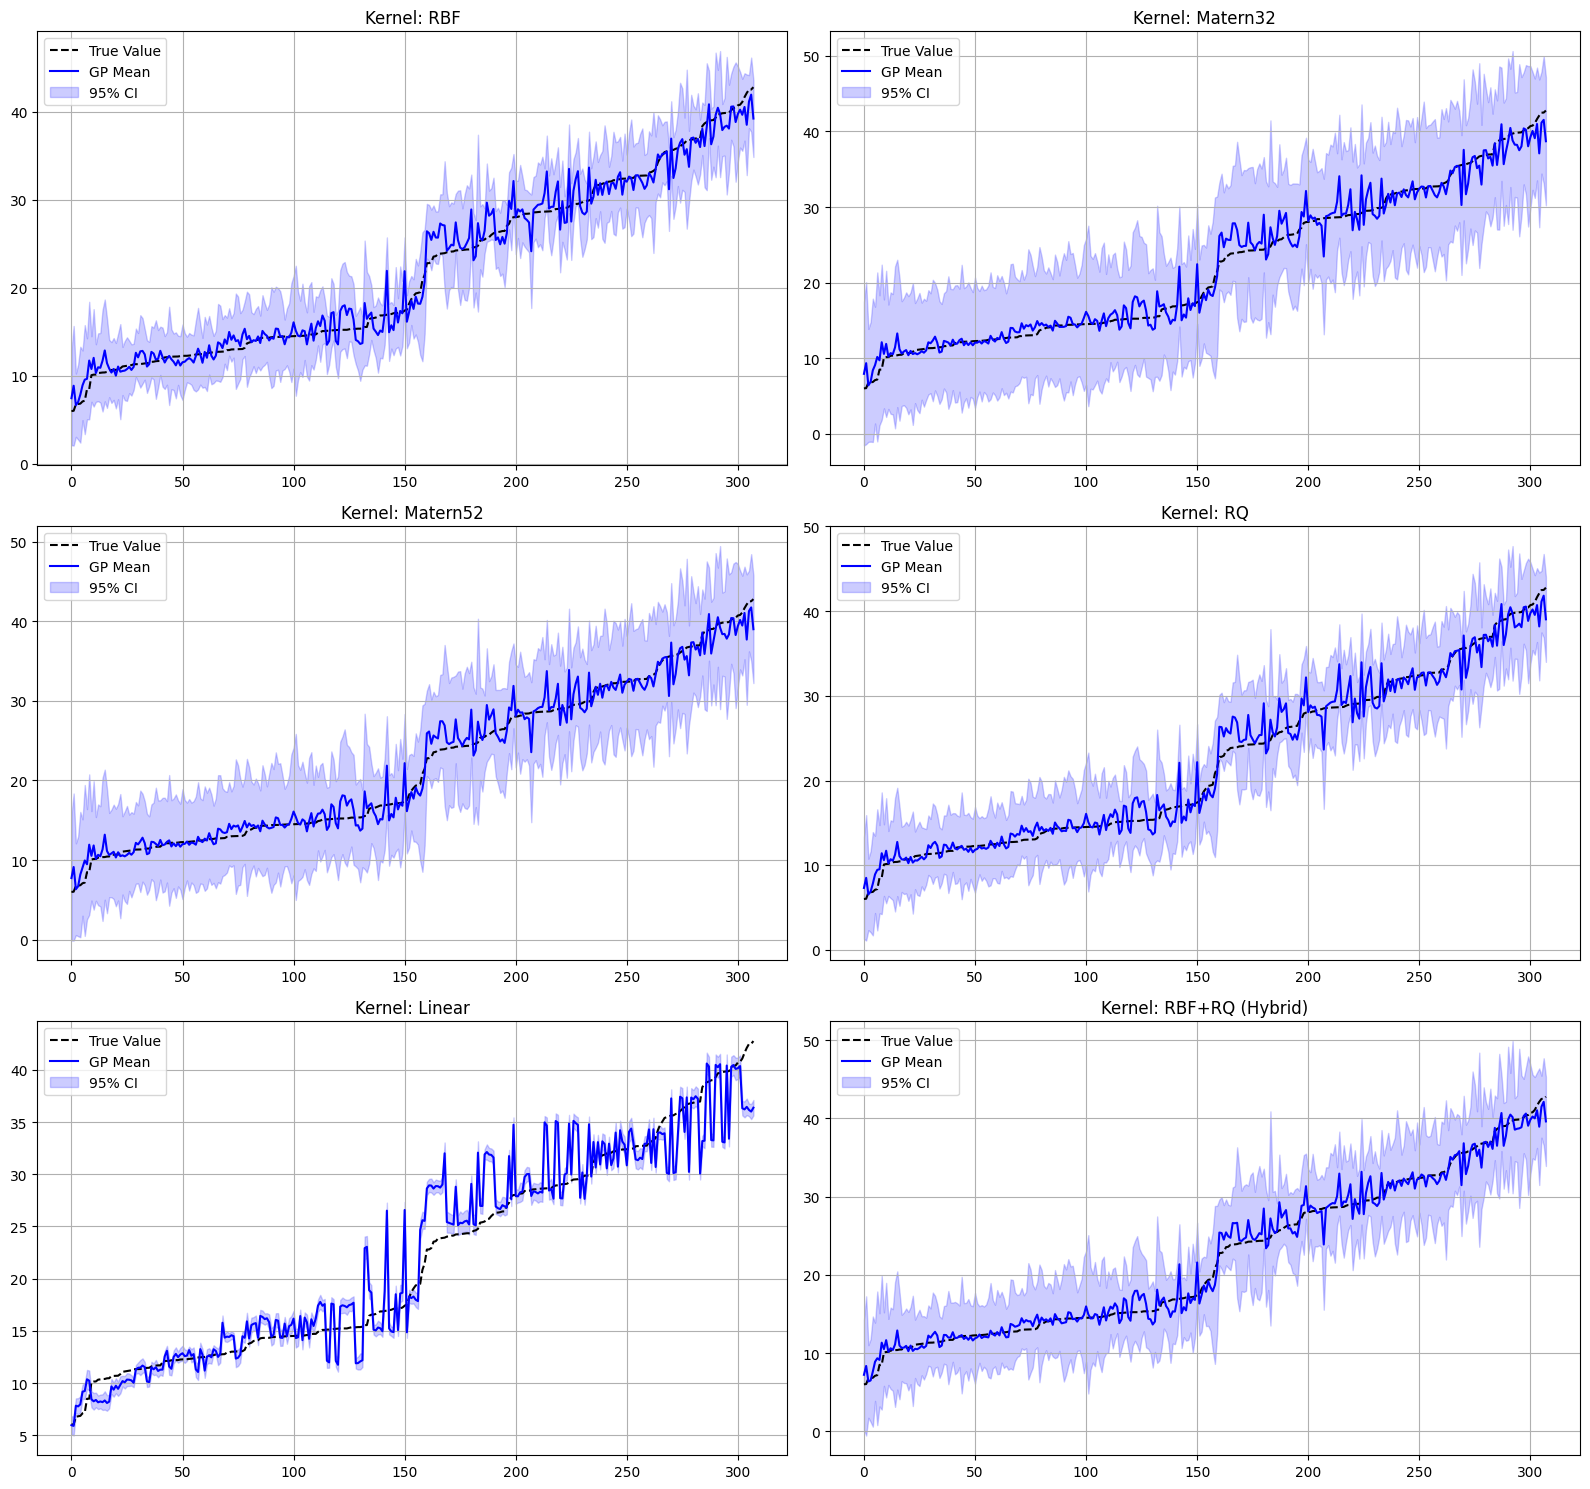

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()
for idx, name in enumerate(results.keys()):
    ax = axes[idx]
    pred = results[name]["mean"]
    std = np.sqrt(results[name]["variance"])
    pred_s = pred[sort_idx]
    std_s = std[sort_idx]
    
    ax.plot(x_axis, Y_test_sorted, 'k--', label='True Value')
    ax.plot(x_axis, pred_s, 'b-', label='GP Mean')
    ax.fill_between(x_axis, pred_s - 1.96*std_s, pred_s + 1.96*std_s, color='blue', alpha=0.2, label='95% CI')
    ax.set_title(f"Kernel: {name}")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


## 6. Comparison with Baseline Machine Learning Models

We implement Linear Regression, Polynomial Regression (Deg 2), KNN, and Decision Tree regressors entirely from scratch using NumPy.


In [16]:
class LinearRegressionFromScratch:
    def fit(self, X, y):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w

class PolynomialRegressionFromScratch:
    def __init__(self, degree=2):
        self.degree = degree
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        return X_bias @ self.w

class KNNRegressorFromScratch:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            idx = np.argsort(dists)[:self.k]
            preds.append(np.mean(self.y_train[idx]))
        return np.array(preds)

class DecisionTreeRegressorFromScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        if depth >= self.max_depth or num_samples < self.min_samples_split or np.std(y) == 0:
            return np.mean(y)
        best_feat, best_thresh, best_mse = None, None, float('inf')
        for feat in range(num_features):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 100:
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 50))
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if not np.any(left_mask) or not np.any(right_mask):
                    continue
                left_y, right_y = y[left_mask], y[right_mask]
                mse = np.sum((left_y - np.mean(left_y))**2) + np.sum((right_y - np.mean(right_y))**2)
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        if best_feat is None:
            return np.mean(y)
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return {"feature": best_feat, "threshold": best_thresh, "left": left_child, "right": right_child}
    def predict(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])
    def _predict_row(self, node, row):
        if not isinstance(node, dict):
            return node
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(node["left"], row)
        else:
            return self._predict_row(node["right"], row)


In [17]:
models_baseline = {
    "Linear Regression": LinearRegressionFromScratch(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionFromScratch(degree=2),
    "K-Nearest Neighbors": KNNRegressorFromScratch(k=5),
    "Decision Tree": DecisionTreeRegressorFromScratch(max_depth=5)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, Y_train_orig)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained from scratch.")


Baseline 'Linear Regression' trained from scratch.
Baseline 'Polynomial Regression (Deg 2)' trained from scratch.
Baseline 'K-Nearest Neighbors' trained from scratch.
Baseline 'Decision Tree' trained from scratch.


In [18]:
# Implement regression metrics from scratch
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))
baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test_orig, y_pred))
    mae = mean_absolute_error(Y_test_orig, y_pred)
    r2 = r2_score(Y_test_orig, y_pred)
    mape = mean_absolute_percentage_error(Y_test_orig, y_pred)
    baseline_results.append([name, rmse, mae, r2, mape])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model      RMSE       MAE        R2      MAPE
3                  Decision Tree  1.037341  0.691548  0.988929  0.028875
1  Polynomial Regression (Deg 2)  2.420561  1.976888  0.939719  0.109384
2            K-Nearest Neighbors  2.495632  1.613169  0.935922  0.075578
0              Linear Regression  2.837534  2.005220  0.917162  0.097821


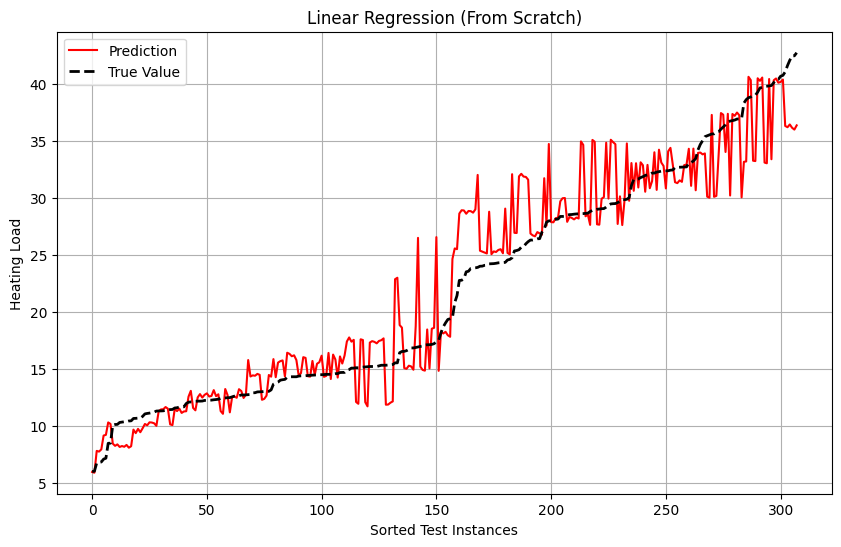

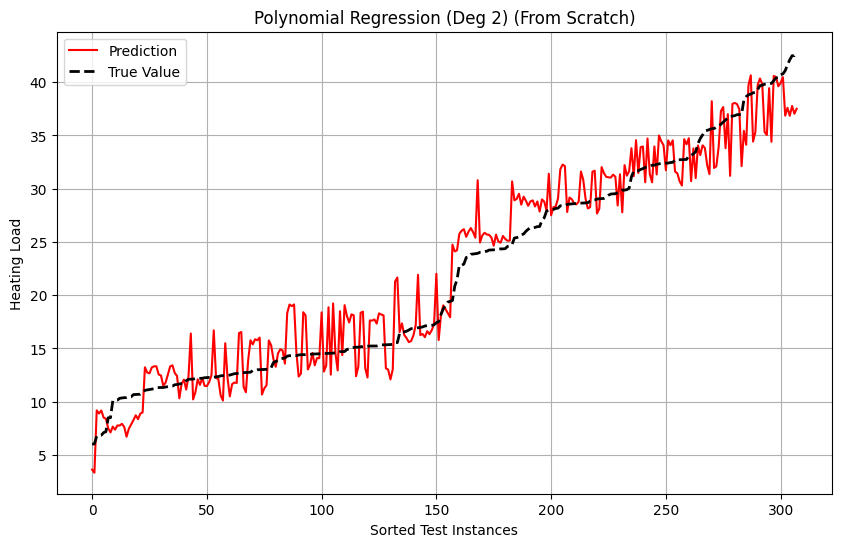

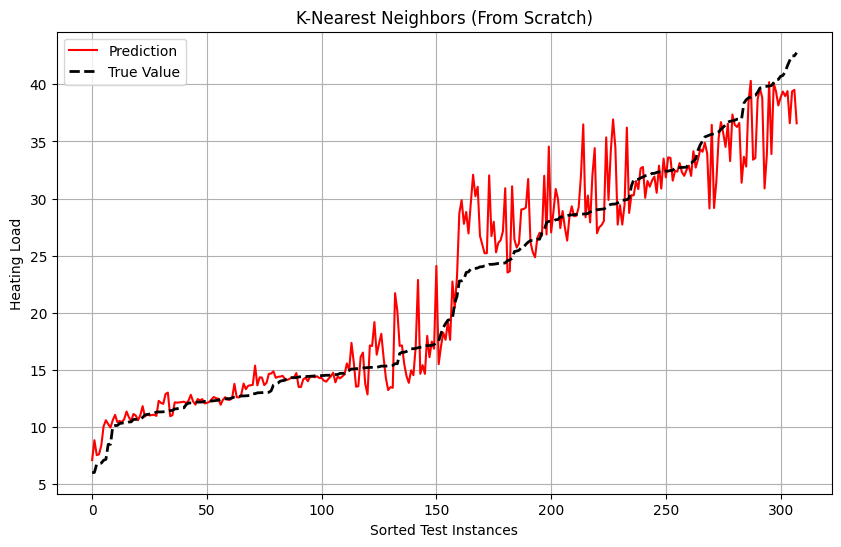

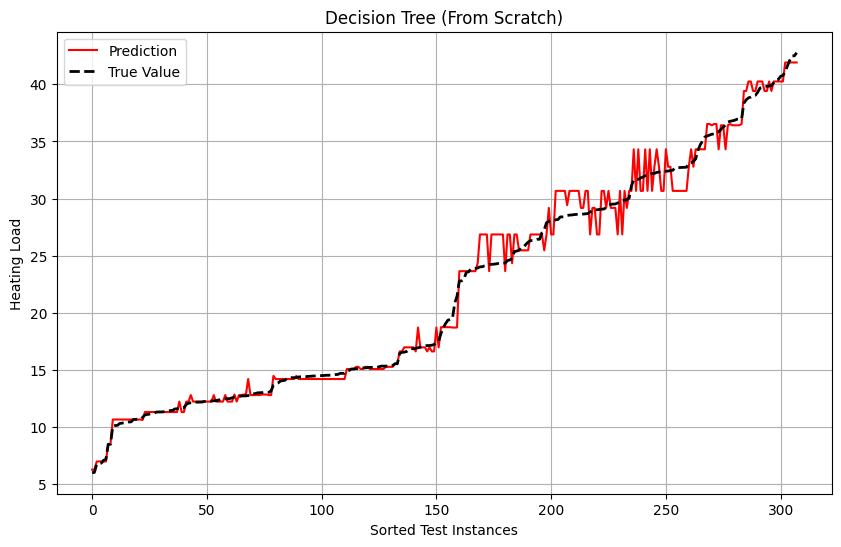

In [19]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    plt.plot(x_axis, y_pred[sort_idx], 'r-', label='Prediction', linewidth=1.5)
    plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
    plt.title(f"{name} (From Scratch)")
    plt.xlabel("Sorted Test Instances")
    plt.ylabel("Heating Load")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Summary and Model Ranking


In [20]:
joint_results = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse = np.sqrt(np.mean((Y_test_orig - pred)**2))
    mape = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([f"GPR ({name})", rmse, accuracy])
    
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([name, rmse, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model      RMSE  Accuracy (%)
9                  Decision Tree  1.037341     97.112524
5          GPR (RBF+RQ (Hybrid))  1.310292     94.982488
2                 GPR (Matern52)  1.524127     94.297399
3                       GPR (RQ)  1.541599     94.301699
0                      GPR (RBF)  1.542573     93.907057
1                 GPR (Matern32)  1.619858     94.008274
7  Polynomial Regression (Deg 2)  2.420561     89.061583
8            K-Nearest Neighbors  2.495632     92.442204
4                   GPR (Linear)  2.836373     90.223182
6              Linear Regression  2.837534     90.217882


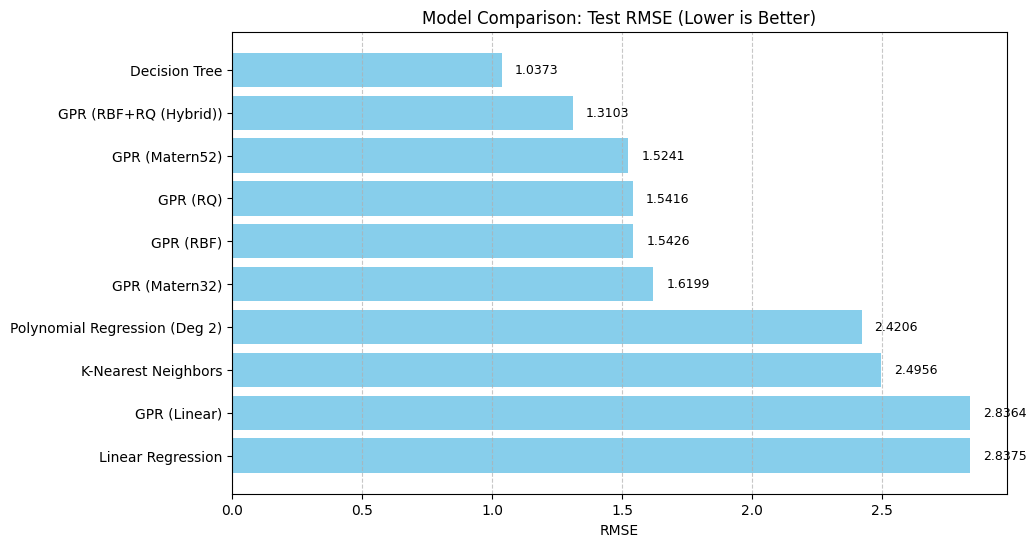

In [21]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"{width:.4f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


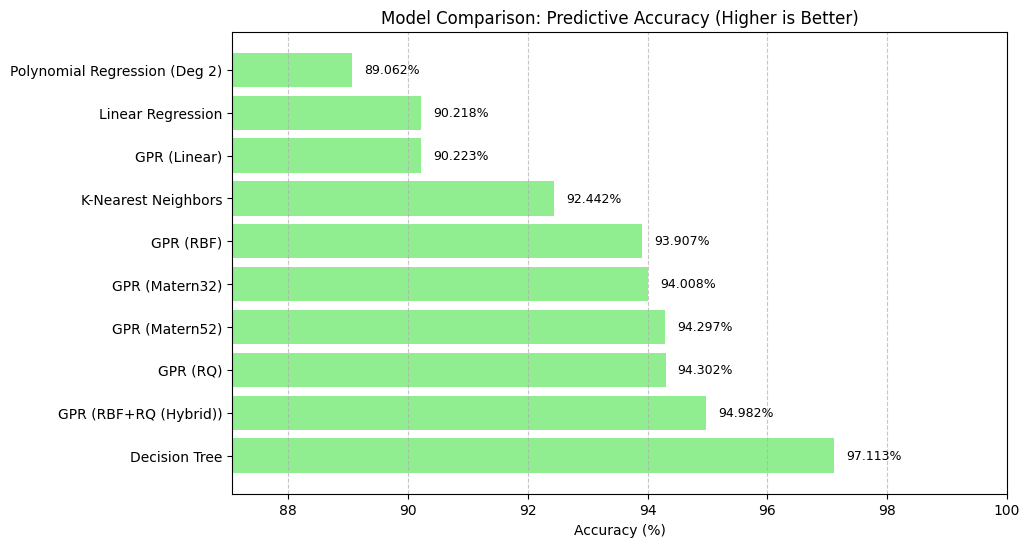

In [22]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
